# PuLP 线性规划示例

下面演示一个简单的线性规划问题：

$$
\max z = 3x + 2y
$$

约束条件为：

$$
\begin{aligned}
x + 2y &\leq 8 \\
3x + y &\leq 9 \\
x &\geq 0 \\
y &\geq 0
\end{aligned}
$$


In [6]:
import pulp

# 1. 创建一个最大化问题
model = pulp.LpProblem('Simple_Linear_Programming', pulp.LpMaximize)

# 2. 定义决策变量
x = pulp.LpVariable('x', lowBound=0, cat='Continuous')
y = pulp.LpVariable('y', lowBound=0, cat='Continuous')

# 3. 定义目标函数
model += 3 * x + 2 * y, 'Objective'

# 4. 添加约束条件
model += x + 2 * y <= 8, 'Constraint_1'
model += 3 * x + y <= 9, 'Constraint_2'

# 5. 求解
model.solve()

# 6. 输出结果
print('求解状态:', pulp.LpStatus[model.status])
print('最优目标值 z =', pulp.value(model.objective))
print('x =', x.varValue)
print('y =', y.varValue)


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/zhangyoulun/codes/zhyoulun/blog/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/94/rtd3cpfd581g16md5_477nrr0000gp/T/668667f42a6642fe86e568421facc955-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/94/rtd3cpfd581g16md5_477nrr0000gp/T/668667f42a6642fe86e568421facc955-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 7 COLUMNS
At line 14 RHS
At line 17 BOUNDS
At line 18 ENDATA
Problem MODEL has 2 rows, 2 columns and 4 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 2 (0) rows, 2 (0) columns and 4 (0) elements
0  Obj -0 Dual inf 4.9999998 (2)
0  Obj -0 Dual inf 4.9999998 (2)
2  Obj 12
Optimal - objective value 12
Optimal objective 12 - 2 iterations time 0.002
Option for printingOptions changed from normal to all
Total time (CPU seconds):

## 使用 Matplotlib 绘制线性规划示意图

下面代码会绘制约束直线、可行域、最优解点，以及目标函数在最优解处的等值线。


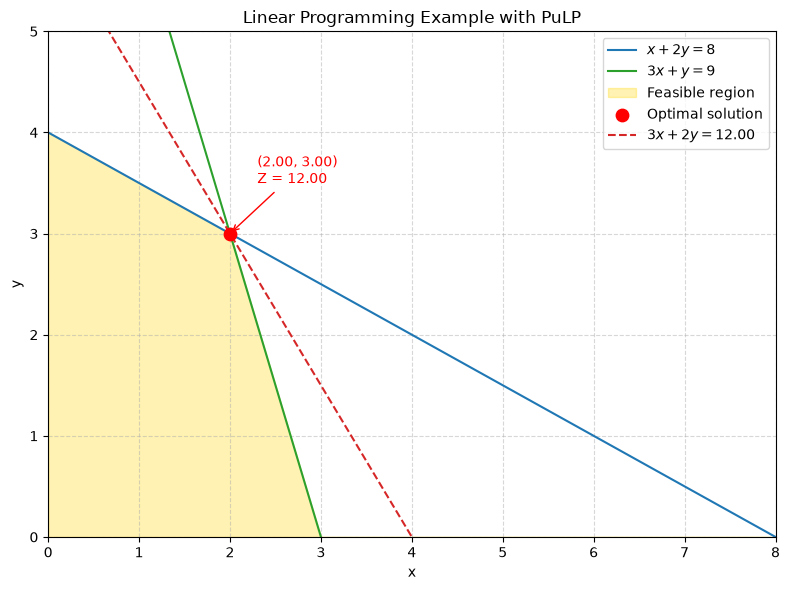

In [7]:
import numpy as np
import matplotlib.pyplot as plt

optimal_x = x.varValue
optimal_y = y.varValue
optimal_z = pulp.value(model.objective)

x_values = np.linspace(0, 8, 400)
y1 = (8 - x_values) / 2
y2 = 9 - 3 * x_values

feasible_top = np.minimum(y1, y2)
feasible_top = np.maximum(feasible_top, 0)

plt.figure(figsize=(8, 6))
plt.plot(x_values, y1, label=r'$x + 2y = 8$', color='tab:blue')
plt.plot(x_values, y2, label=r'$3x + y = 9$', color='tab:green')
plt.fill_between(
    x_values,
    0,
    feasible_top,
    where=feasible_top >= 0,
    color='gold',
    alpha=0.3,
    label='Feasible region'
)

plt.scatter(optimal_x, optimal_y, color='red', s=80, zorder=5, label='Optimal solution')
plt.annotate(
    f'({optimal_x:.2f}, {optimal_y:.2f})\nZ = {optimal_z:.2f}',
    xy=(optimal_x, optimal_y),
    xytext=(optimal_x + 0.3, optimal_y + 0.5),
    arrowprops={'arrowstyle': '->', 'color': 'red'},
    color='red'
)

objective_y = (optimal_z - 3 * x_values) / 2
plt.plot(
    x_values,
    objective_y,
    linestyle='--',
    color='tab:red',
    label=rf'$3x + 2y = {optimal_z:.2f}$'
)

plt.xlim(0, 8)
plt.ylim(0, 5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Programming Example with PuLP')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
